"""
Deep Feed-Forward Neural Network (2 Hidden Layers) for Multiclass Classification
Every line below has an inline comment explaining exactly what it does.
"""

In [7]:
import numpy as np                                                    # numerical arrays / math operations
import matplotlib.pyplot as plt                                       # for plotting accuracy/loss graphs
from sklearn.datasets import load_iris                                # built-in Iris dataset (no internet needed)
from sklearn.model_selection import train_test_split                  # splits data into train/test sets
from sklearn.preprocessing import StandardScaler                      # scales features to mean=0, std=1
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # evaluation metrics

import tensorflow as tf                                               # deep learning framework
from tensorflow import keras                                          # high-level API for building NNs
from tensorflow.keras import layers                                   # layer building blocks (Dense, Input, etc.)

In [8]:
# ---------------------------------------------------------------------
# 1. Load and prepare the data
# ---------------------------------------------------------------------
data = load_iris()                                                    # loads the Iris dataset object
X = data.data                                                         # feature matrix, shape (150, 4)
y = data.target                                                       # integer labels 0/1/2, shape (150,)
class_names = data.target_names                                       # ['setosa' 'versicolor' 'virginica']
num_classes = len(class_names)                                        # = 3, number of output classes
num_features = X.shape[1]                                             # = 4, number of input features

X_train, X_test, y_train, y_test = train_test_split(                  # split data into training/testing sets
    X, y, test_size=0.2, random_state=42, stratify=y                  # 20% test, fixed seed, keep class balance
)                                                                      # end of train_test_split call

scaler = StandardScaler()                                             # create a scaler object
X_train = scaler.fit_transform(X_train)                               # fit scaler on train data & transform it
X_test = scaler.transform(X_test)                                     # transform test data using same scaler

y_train_cat = keras.utils.to_categorical(y_train, num_classes=num_classes)  # one-hot encode train labels
y_test_cat = keras.utils.to_categorical(y_test, num_classes=num_classes)    # one-hot encode test labels


In [9]:
# ---------------------------------------------------------------------
# 2. Build the Deep Feed-Forward Network (2 hidden layers)
# ---------------------------------------------------------------------
model = keras.Sequential([                                            # start defining a sequential (layer-stack) model
    layers.Input(shape=(num_features,)),                              # input layer, expects 4 features per sample
    layers.Dense(16, activation='relu', name='hidden_layer_1'),       # hidden layer 1: 16 neurons, ReLU activation
    layers.Dense(8, activation='relu', name='hidden_layer_2'),        # hidden layer 2: 8 neurons, ReLU activation
    layers.Dense(num_classes, activation='softmax', name='output_layer')  # output layer: 3 neurons, softmax probs
])                                                                     # end of Sequential model definition

model.compile(                                                        # configure the model for training
    optimizer=keras.optimizers.Adam(learning_rate=0.01),              # Adam optimizer with learning rate 0.01
    loss='categorical_crossentropy',                                  # loss function for multiclass one-hot labels
    metrics=['accuracy']                                              # track accuracy during training
)                                                                      # end of compile call

model.summary()                                                       # print a summary of layers/parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ---------------------------------------------------------------------
# 3. Train the network
# ---------------------------------------------------------------------
history = model.fit(                                                  # train the model, store training history
    X_train, y_train_cat,                                             # training features and one-hot labels
    validation_split=0.2,                                             # use 20% of training data for validation
    epochs=100,                                                       # number of full passes over training data
    batch_size=8,                                                     # number of samples per gradient update
    verbose=0                                                         # suppress per-epoch console output
)                                                                      # end of fit call

In [11]:
# ---------------------------------------------------------------------
# 4. Evaluate on the test set
# ---------------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)   # evaluate model on unseen test data
print(f"\nTest Accuracy : {test_acc*100:.2f}%")                       # print test accuracy as a percentage
print(f"Test Loss     : {test_loss:.4f}")                             # print test loss value

y_pred_probs = model.predict(X_test, verbose=0)                       # get predicted class probabilities for test set
y_pred = np.argmax(y_pred_probs, axis=1)                              # convert probabilities to class index (0/1/2)

print("\nClassification Report:\n")                                   # header text for report
print(classification_report(y_test, y_pred, target_names=class_names))# print precision/recall/f1 per class

print("Confusion Matrix:\n")                                          # header text for confusion matrix
print(confusion_matrix(y_test, y_pred))                               # print confusion matrix (rows=true, cols=pred)


Test Accuracy : 93.33%
Test Loss     : 0.1312

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:

[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [12]:
# ---------------------------------------------------------------------
# 5. Predict the class of a brand-new sample
# ---------------------------------------------------------------------
new_sample = np.array([[5.9, 3.0, 5.1, 1.8]])                         # a new unseen flower measurement (1 row, 4 cols)
new_sample_scaled = scaler.transform(new_sample)                      # scale it using the SAME scaler as training data

pred_probs = model.predict(new_sample_scaled, verbose=0)              # get predicted probabilities for the new sample
pred_class = np.argmax(pred_probs, axis=1)[0]                         # pick the class with highest probability

print(f"\nNew sample : {new_sample.tolist()[0]}")                     # print the raw input values
print(f"Predicted class index : {pred_class}")                        # print predicted numeric class (0/1/2)
print(f"Predicted class label : {class_names[pred_class]}")           # print predicted species name
print(f"Class probabilities   : {np.round(pred_probs[0], 3)}")        # print probability for each of the 3 classes


New sample : [5.9, 3.0, 5.1, 1.8]
Predicted class index : 2
Predicted class label : virginica
Class probabilities   : [0.    0.012 0.988]



Saved training curves to 'ffn_training_curves.png'


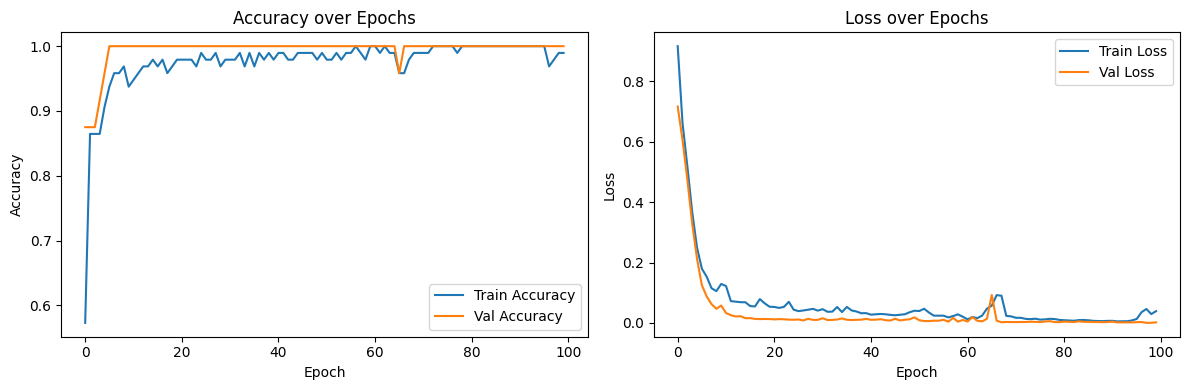

In [13]:
# ---------------------------------------------------------------------
# 6. Plot training curves
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                       # create a figure with 2 side-by-side subplots

axes[0].plot(history.history['accuracy'], label='Train Accuracy')     # plot training accuracy per epoch
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')   # plot validation accuracy per epoch
axes[0].set_title('Accuracy over Epochs')                             # title for the accuracy subplot
axes[0].set_xlabel('Epoch')                                           # x-axis label
axes[0].set_ylabel('Accuracy')                                        # y-axis label
axes[0].legend()                                                      # show legend distinguishing train/val lines

axes[1].plot(history.history['loss'], label='Train Loss')             # plot training loss per epoch
axes[1].plot(history.history['val_loss'], label='Val Loss')           # plot validation loss per epoch
axes[1].set_title('Loss over Epochs')                                 # title for the loss subplot
axes[1].set_xlabel('Epoch')                                           # x-axis label
axes[1].set_ylabel('Loss')                                            # y-axis label
axes[1].legend()                                                      # show legend distinguishing train/val lines

plt.tight_layout()                                                    # auto-adjust spacing so subplots don't overlap
plt.savefig('ffn_training_curves.png', dpi=150)                       # save the figure to a PNG file
print("\nSaved training curves to 'ffn_training_curves.png'")         # confirm to the user where the plot was saved

"""
Deep Learning based Image Segmentation using a U-Net Convolutional Network
Every line below has an inline comment explaining exactly what it does.
"""

In [14]:
import numpy as np                                                    # numerical arrays / math operations
import matplotlib.pyplot as plt                                       # for visualizing images/masks and curves

import tensorflow as tf                                               # deep learning framework
from tensorflow import keras                                          # high-level API for building NNs
from tensorflow.keras import layers                                   # layer building blocks (Conv2D, etc.)

In [15]:
# ---------------------------------------------------------------------
# 0. Reproducibility
# ---------------------------------------------------------------------
np.random.seed(42)                                                    # fix numpy's random seed for repeatable results
tf.random.set_seed(42)                                                # fix tensorflow's random seed for repeatable results

IMG_SIZE = 64                                                         # each image will be 64x64 pixels
NUM_SAMPLES = 400                                                     # total number of synthetic images to generate
BATCH_SIZE = 16                                                       # number of images per training batch
EPOCHS = 20                                                           # number of full training passes

In [16]:
# ---------------------------------------------------------------------
# 1. Create a synthetic image-segmentation dataset
# ---------------------------------------------------------------------
def generate_synthetic_dataset(n_samples, img_size):                  # function to build fake images + masks
    """Generates grayscale images with a random circle or square drawn on
    them, plus the matching binary mask (1 = object/foreground, 0 = background)."""
    images = np.zeros((n_samples, img_size, img_size, 1), dtype=np.float32)  # empty array to hold all images
    masks = np.zeros((n_samples, img_size, img_size, 1), dtype=np.float32)   # empty array to hold all masks

    yy, xx = np.mgrid[0:img_size, 0:img_size]                         # grid of pixel row/col coordinates

    for i in range(n_samples):                                        # loop once per image to generate
        img = np.random.uniform(0.0, 0.2, size=(img_size, img_size))  # start with dark random noise background
        mask = np.zeros((img_size, img_size), dtype=np.float32)       # start mask as all-zero (background)

        cx = np.random.randint(img_size // 4, 3 * img_size // 4)      # random x-center for the shape
        cy = np.random.randint(img_size // 4, 3 * img_size // 4)      # random y-center for the shape
        size = np.random.randint(img_size // 8, img_size // 4)        # random size (radius/half-width) of shape
        intensity = np.random.uniform(0.7, 1.0)                       # random brightness for the shape pixels

        if np.random.rand() > 0.5:                                    # 50% chance: draw a circle
            dist = (xx - cx) ** 2 + (yy - cy) ** 2                    # squared distance of every pixel from center
            shape_mask = dist <= size ** 2                            # True for pixels inside the circle radius
        else:                                                         # otherwise: draw a square
            shape_mask = (np.abs(xx - cx) <= size) & (np.abs(yy - cy) <= size)  # True for pixels inside the square

        img[shape_mask] = intensity                                   # paint the shape onto the image
        mask[shape_mask] = 1.0                                        # mark those same pixels as foreground in mask

        images[i, :, :, 0] = img                                      # store this image in the dataset array
        masks[i, :, :, 0] = mask                                      # store this mask in the dataset array

    return images, masks                                              # return the full set of images and masks


X, Y = generate_synthetic_dataset(NUM_SAMPLES, IMG_SIZE)              # generate the dataset (images X, masks Y)

split = int(0.8 * NUM_SAMPLES)                                        # index marking 80% train / 20% test split
X_train, Y_train = X[:split], Y[:split]                               # first 80% of data used for training
X_test, Y_test = X[split:], Y[split:]                                 # remaining 20% of data used for testing

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")        # print dataset shapes for sanity check

Train set: (320, 64, 64, 1), Test set: (80, 64, 64, 1)


In [17]:
# ---------------------------------------------------------------------
# 2. Build a compact U-Net model
# ---------------------------------------------------------------------
def conv_block(x, filters):                                           # reusable block: two conv layers in a row
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)  # 3x3 conv, same padding, ReLU activation
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)  # second 3x3 conv, same padding, ReLU
    return x                                                          # return the processed feature map


def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 1)):                  # function that builds the full U-Net model
    inputs = keras.Input(shape=input_shape)                           # input layer: 64x64 grayscale image

    # ---- Encoder (downsampling) ----
    c1 = conv_block(inputs, 16)                                       # encoder block 1: 16 filters, 64x64 resolution
    p1 = layers.MaxPooling2D()(c1)                                    # downsample by 2 -> 32x32

    c2 = conv_block(p1, 32)                                           # encoder block 2: 32 filters, 32x32 resolution
    p2 = layers.MaxPooling2D()(c2)                                    # downsample by 2 -> 16x16

    # ---- Bottleneck ----
    b = conv_block(p2, 64)                                            # deepest layer: 64 filters, 16x16 resolution

    # ---- Decoder (upsampling) ----
    u2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(b)  # upsample bottleneck back to 32x32
    u2 = layers.Concatenate()([u2, c2])                               # skip connection: merge with encoder block 2
    d2 = conv_block(u2, 32)                                           # decoder block: refine merged features

    u1 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(d2) # upsample back to 64x64
    u1 = layers.Concatenate()([u1, c1])                               # skip connection: merge with encoder block 1
    d1 = conv_block(u1, 16)                                           # decoder block: refine merged features

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)           # 1x1 conv -> single-channel mask, sigmoid probs

    return keras.Model(inputs, outputs, name='mini_unet')             # wrap input/output into a trainable Model


model = build_unet()                                                  # instantiate the U-Net model
model.summary()                                                       # print a summary of layers/parameters

Model: "mini_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        160 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │      8,224 │ conv2d_5[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     18,464 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │      2,064 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │      4,624 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │      2,320 │ conv2d_8[0][0]  

 Total params: 116,753 (456.07 KB)

 Trainable params: 116,753 (456.07 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ---------------------------------------------------------------------
# 3. Custom metric: Dice coefficient (common for segmentation quality)
# ---------------------------------------------------------------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):                    # function to compute Dice similarity score
    y_true_f = tf.reshape(y_true, [-1])                                # flatten ground-truth mask to 1D
    y_pred_f = tf.reshape(y_pred, [-1])                                # flatten predicted mask to 1D
    intersection = tf.reduce_sum(y_true_f * y_pred_f)                  # count of overlapping foreground pixels
    return (2.0 * intersection + smooth) / (                           # Dice formula: 2*overlap / (sum of both)
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth      # smooth avoids divide-by-zero
    )                                                                  # end of Dice calculation


model.compile(                                                        # configure the model for training
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),              # Adam optimizer, learning rate 0.001
    loss='binary_crossentropy',                                       # pixel-wise binary classification loss
    metrics=['accuracy', dice_coefficient]                            # track pixel accuracy and Dice score
)                                                                      # end of compile call

In [19]:
# ---------------------------------------------------------------------
# 4. Train the network
# ---------------------------------------------------------------------
history = model.fit(                                                  # train the model, store training history
    X_train, Y_train,                                                 # training images and their ground-truth masks
    validation_split=0.1,                                             # hold out 10% of training data for validation
    batch_size=BATCH_SIZE,                                            # number of images per gradient update
    epochs=EPOCHS,                                                    # number of full passes over training data
    verbose=1                                                         # print progress bar for each epoch
)                                                                      # end of fit call

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.9010 - dice_coefficient: 0.2674 - loss: 0.5233 - val_accuracy: 0.9884 - val_dice_coefficient: 0.7425 - val_loss: 0.0715
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9881 - dice_coefficient: 0.9023 - loss: 0.0350 - val_accuracy: 0.9944 - val_dice_coefficient: 0.9554 - val_loss: 0.0143
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9974 - dice_coefficient: 0.9708 - loss: 0.0097 - val_accuracy: 0.9976 - val_dice_coefficient: 0.9781 - val_loss: 0.0073
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9983 - dice_coefficient: 0.9841 - loss: 0.0060 - val_accuracy: 0.9986 - val_dice_coefficient: 0.9865 - val_loss: 0.0051
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9986 - dice_coefficient: 0.9873 - loss: 0.0047 - val_accuracy: 0.9987 - val_dice_coefficient: 0.9887 - val_loss: 0.0042
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9988 - d


Test Loss : 0.0006
Test Accuracy : 99.98%
Test Dice Coefficient : 0.9979

Saved sample predictions to 'segmentation_results.png'


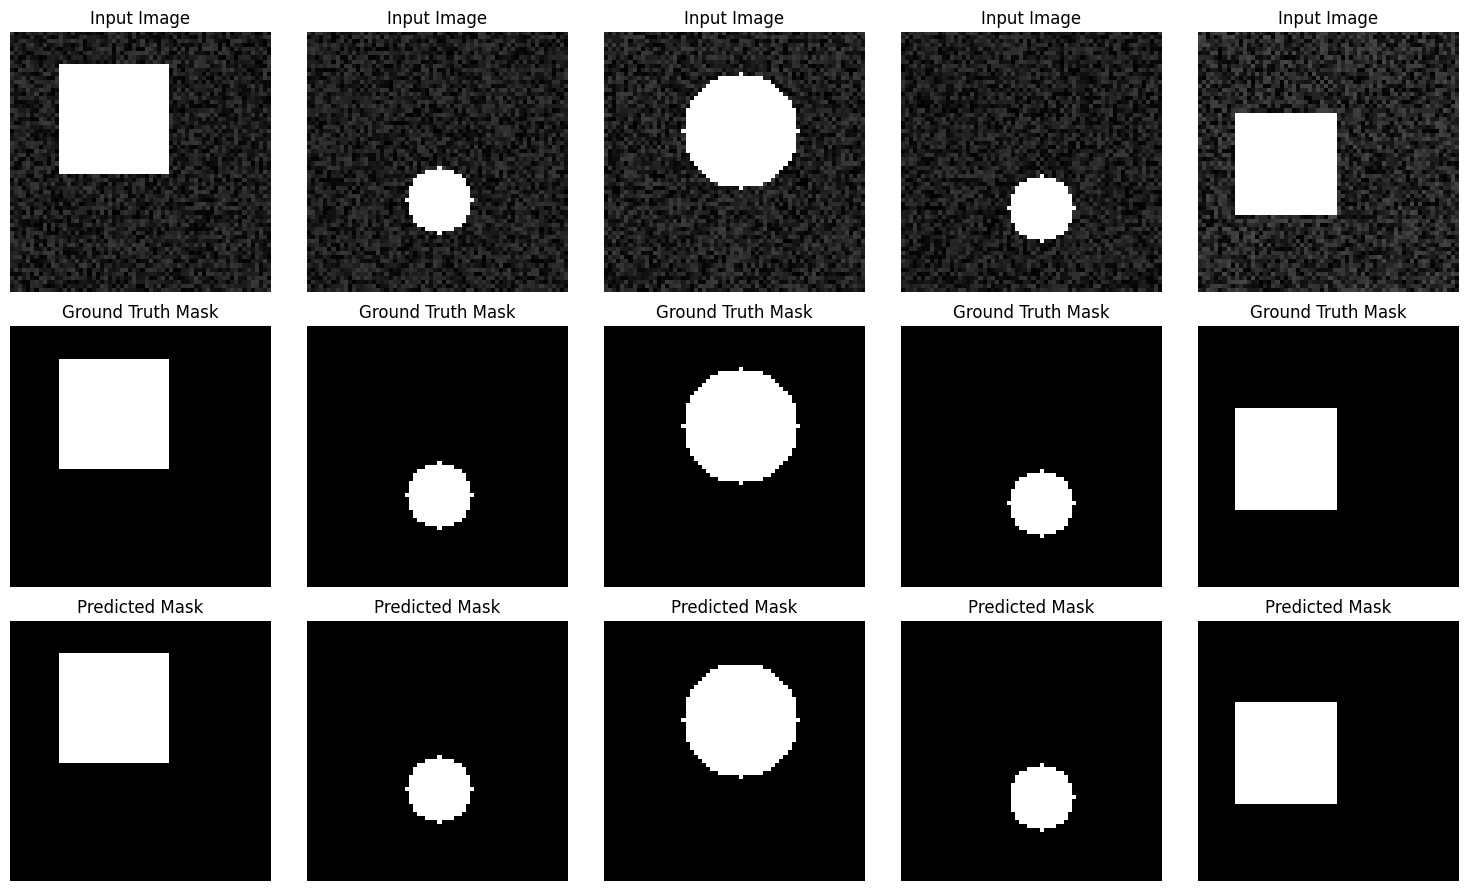

In [20]:
# ---------------------------------------------------------------------
# 5. Evaluate on the held-out test set
# ---------------------------------------------------------------------
results = model.evaluate(X_test, Y_test, verbose=0)                   # evaluate model on unseen test images
print(f"\nTest Loss : {results[0]:.4f}")                              # print test loss
print(f"Test Accuracy : {results[1]*100:.2f}%")                       # print test pixel-wise accuracy
print(f"Test Dice Coefficient : {results[2]:.4f}")                    # print test Dice score

# ---------------------------------------------------------------------
# 6. Visualize predictions on a few test images
# ---------------------------------------------------------------------
preds = model.predict(X_test[:5], verbose=0)                          # predict masks for first 5 test images
pred_masks = (preds > 0.5).astype(np.float32)                         # threshold probabilities at 0.5 -> binary mask

fig, axes = plt.subplots(3, 5, figsize=(15, 9))                       # figure with 3 rows (input/truth/pred), 5 cols
for i in range(5):                                                    # loop over the 5 sample images
    axes[0, i].imshow(X_test[i, :, :, 0], cmap='gray')                # show the input image
    axes[0, i].set_title('Input Image')                               # label the top row
    axes[0, i].axis('off')                                            # hide axis ticks/labels

    axes[1, i].imshow(Y_test[i, :, :, 0], cmap='gray')                # show the ground-truth mask
    axes[1, i].set_title('Ground Truth Mask')                         # label the middle row
    axes[1, i].axis('off')                                            # hide axis ticks/labels

    axes[2, i].imshow(pred_masks[i, :, :, 0], cmap='gray')            # show the model's predicted mask
    axes[2, i].set_title('Predicted Mask')                            # label the bottom row
    axes[2, i].axis('off')                                            # hide axis ticks/labels

plt.tight_layout()                                                    # auto-adjust spacing so subplots don't overlap
plt.savefig('segmentation_results.png', dpi=150)                      # save the comparison figure to a PNG file
print("\nSaved sample predictions to 'segmentation_results.png'")     # confirm to the user where the plot was saved


Saved training curves to 'segmentation_training_curves.png'


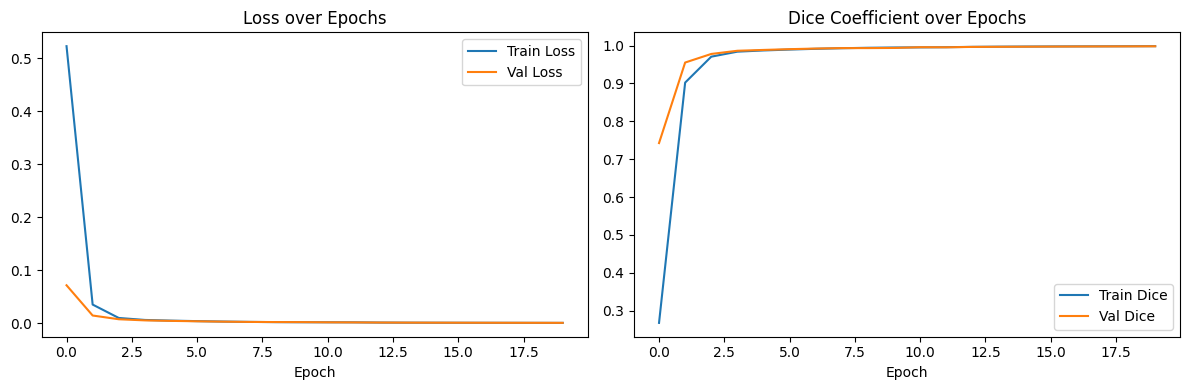

In [21]:
# ---------------------------------------------------------------------
# 7. Plot training curves
# ---------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))                     # figure with 2 side-by-side subplots
axes2[0].plot(history.history['loss'], label='Train Loss')            # plot training loss per epoch
axes2[0].plot(history.history['val_loss'], label='Val Loss')          # plot validation loss per epoch
axes2[0].set_title('Loss over Epochs')                                # title for loss subplot
axes2[0].set_xlabel('Epoch')                                          # x-axis label
axes2[0].legend()                                                     # show legend distinguishing train/val lines

axes2[1].plot(history.history['dice_coefficient'], label='Train Dice')     # plot training Dice score per epoch
axes2[1].plot(history.history['val_dice_coefficient'], label='Val Dice')   # plot validation Dice score per epoch
axes2[1].set_title('Dice Coefficient over Epochs')                    # title for Dice subplot
axes2[1].set_xlabel('Epoch')                                          # x-axis label
axes2[1].legend()                                                     # show legend distinguishing train/val lines

plt.tight_layout()                                                    # auto-adjust spacing so subplots don't overlap
plt.savefig('segmentation_training_curves.png', dpi=150)              # save the curves figure to a PNG file
print("Saved training curves to 'segmentation_training_curves.png'") # confirm to the user where the plot was saved